# SmolVLA Optuna HPO (Colab) - v3

Run 30-trial Optuna HPO on Colab GPU to find optimal SmolVLA hyperparameters.

- **Dataset:** `AdithyaRajendran/so101_grab_brain_t2` (241 episodes, 100832 frames)
- **Task:** *"Grab the grey brain toy and place it inside the green container"*
- **Trials:** 30 (5 seeded + 25 TPE), 2000 steps each
- **Pruner:** MedianPruner (kills bad trials early)
- **Metric:** Average loss over final 500 steps
- **Auto-backup:** Saves DB to Google Drive after every trial

### Why 30 trials x 2000 steps?
- 8 hyperparameters → ~30 trials is the sweet spot for TPE
- 2000 steps (16K samples) is enough to rank configs by relative loss
- 5 strategic seeded trials give TPE diverse starting points
- MedianPruner kills bad trials after step 500, saving ~50% time

### Estimated runtime:
| GPU | batch_size | Per trial | 30 trials (w/ pruning) |
|-----|-----------|-----------|------------------------|
| T4 (free) | 4 | ~7 min | ~2.5-3 hrs |
| L4 (Pro) | 8 | ~4 min | ~1.5-2 hrs |
| A100 (Pro) | 8 | ~3 min | ~1-1.5 hrs |

In [26]:
# Check GPU
import torch, platform

print("Python:", platform.python_version())
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    VRAM_GB = round(props.total_memory / 1024**3, 2)
    print(f"GPU: {props.name}")
    print(f"VRAM (GB): {VRAM_GB}")
else:
    raise RuntimeError("No GPU! Go to Runtime > Change runtime type > GPU")

Python: 3.12.12
Torch: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB
VRAM (GB): 39.49


In [27]:
%%bash
# Install LeRobot + SmolVLA deps
cd /content

if [ ! -d lerobot ]; then
  git clone https://github.com/huggingface/lerobot.git
fi

cd /content/lerobot

apt-get -qq update && apt-get -qq install -y ffmpeg

pip install -q "huggingface-hub[cli,hf-transfer]>=0.34.2,<0.36.0" "setuptools>=71.0.0,<81.0.0"
pip install -q -e ".[smolvla]"
pip install -q optuna matplotlib

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [28]:
%%bash
# Authenticate with Hugging Face (replace with your token)
huggingface-cli login --token YOUR_HF_TOKEN_HERE

⚠️  Warning: 'huggingface-cli login' is deprecated. Use 'hf auth login' instead.


The token has not been saved to the git credentials helper. Pass `add_to_git_credential=True` in this function directly or `--add-to-git-credential` if using via `hf`CLI if you want to set the git credential as well.
Token is valid (permission: write).
The token `Pi0.5` has been saved to /root/.cache/huggingface/stored_tokens
Your token has been saved to /root/.cache/huggingface/token
Login successful.
The current active token is: `Pi0.5`


In [29]:
import subprocess
import re
import shutil
import json
import time
from pathlib import Path

import torch
import optuna
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler

In [30]:
# === CONFIGURATION ===

LEROBOT_DIR = Path("/content/lerobot")
TRAIN_SCRIPT = LEROBOT_DIR / "src" / "lerobot" / "scripts" / "lerobot_train.py"
OUTPUT_BASE = Path("/content/optuna_hpo")
DB_PATH = OUTPUT_BASE / "optuna_smolvla.db"
STUDY_NAME = "smolvla_hpo_colab_v3"

DATASET_REPO_ID = "AdithyaRajendran/so101_grab_brain_t2"
POLICY_PATH = "lerobot/smolvla_base"

# Auto-detect batch size based on GPU VRAM
VRAM_GB = torch.cuda.get_device_properties(0).total_memory / 1024**3
if VRAM_GB >= 40:      # A100
    BATCH_SIZE = 8
elif VRAM_GB >= 20:    # L4
    BATCH_SIZE = 8
elif VRAM_GB >= 14:    # T4
    BATCH_SIZE = 4
else:
    BATCH_SIZE = 2

# --- 30 TRIALS x 2000 STEPS (optimized for best signal in shortest time) ---
STEPS_PER_TRIAL = 2000   # 16K samples = enough to rank configs
N_TRIALS = 30            # Sweet spot for 8 hyperparams with TPE
LOG_FREQ = 100           # 20 log entries per trial

# Fixed augmentation params (not worth tuning - low impact)
SHARPNESS_RANGE = [0.5, 1.5]
HUE_RANGE = [-0.05, 0.05]
SATURATION_RANGE = [0.5, 1.5]

# Google Drive backup (auto-saves after every trial for resume)
DRIVE_BACKUP_PATH = "/content/drive/MyDrive/optuna_smolvla_v3.db"

OUTPUT_BASE.mkdir(parents=True, exist_ok=True)

print(f"GPU: {torch.cuda.get_device_properties(0).name} ({VRAM_GB:.1f} GB)")
print(f"Auto-selected batch_size: {BATCH_SIZE}")
print(f"Study: {STUDY_NAME}")
print(f"Steps/trial: {STEPS_PER_TRIAL:,}  |  Trials: {N_TRIALS}")
print(f"Samples per trial: {STEPS_PER_TRIAL * BATCH_SIZE:,} / {100832} ({STEPS_PER_TRIAL * BATCH_SIZE / 100832 * 100:.1f}% of dataset)")
est_mins = N_TRIALS * (STEPS_PER_TRIAL / 3500 * 19)  # scale from v2 timing
print(f"Estimated time (no pruning): ~{est_mins / 60:.1f} hrs on A100")
print(f"Estimated time (with pruning): ~{est_mins / 60 * 0.6:.1f} hrs on A100")

GPU: NVIDIA A100-SXM4-40GB (39.5 GB)
Auto-selected batch_size: 8
Study: smolvla_hpo_colab_v3
Steps/trial: 2,000  |  Trials: 30
Samples per trial: 16,000 / 100832 (15.9% of dataset)
Estimated time (no pruning): ~5.4 hrs on A100
Estimated time (with pruning): ~3.3 hrs on A100


In [31]:
def build_train_command(trial_params, output_dir):
    """Build the lerobot_train.py CLI command from trial parameters."""
    p = trial_params

    norm_map = json.dumps({
        "ACTION": "MEAN_STD",
        "STATE": "MEAN_STD",
        "VISUAL": "IDENTITY",
    })

    rename_map = json.dumps({
        "observation.images.front": "observation.images.camera1",
        "observation.images.wrist": "observation.images.camera2",
    })

    affine_degrees = p["affine_degrees"]
    affine_translate = p["affine_translate"]
    brightness = p["color_jitter_brightness"]
    contrast = p["color_jitter_contrast"]

    # Build image transforms as a single JSON dict
    # (draccus cannot parse nested --dataset.image_transforms.tfs.X.Y.Z args)
    tfs_dict = {
        "brightness": {
            "type": "ColorJitter",
            "kwargs": {"brightness": [round(1.0 - brightness, 3), round(1.0 + brightness, 3)]}
        },
        "contrast": {
            "type": "ColorJitter",
            "kwargs": {"contrast": [round(1.0 - contrast, 3), round(1.0 + contrast, 3)]}
        },
        "saturation": {
            "type": "ColorJitter",
            "kwargs": {"saturation": [SATURATION_RANGE[0], SATURATION_RANGE[1]]}
        },
        "hue": {
            "type": "ColorJitter",
            "kwargs": {"hue": [HUE_RANGE[0], HUE_RANGE[1]]}
        },
        "sharpness": {
            "type": "SharpnessJitter",
            "kwargs": {"sharpness": [SHARPNESS_RANGE[0], SHARPNESS_RANGE[1]]}
        },
        "affine": {
            "type": "RandomAffine",
            "kwargs": {
                "degrees": [round(-affine_degrees, 2), round(affine_degrees, 2)],
                "translate": [round(affine_translate, 4), round(affine_translate, 4)]
            }
        },
    }

    cmd = [
        "python", str(TRAIN_SCRIPT),
        f"--dataset.repo_id={DATASET_REPO_ID}",
        f"--output_dir={output_dir}",
        f"--job_name=optuna_trial",
        f"--policy.path={POLICY_PATH}",
        f"--policy.push_to_hub=false",
        f"--policy.chunk_size={p['chunk_size']}",
        f"--policy.n_action_steps={p['n_action_steps']}",
        f"--policy.optimizer_lr={p['learning_rate']}",
        f"--policy.optimizer_weight_decay={p['weight_decay']}",
        f"--policy.train_expert_only={str(p['train_expert_only']).lower()}",
        f"--policy.freeze_vision_encoder={str(p['freeze_vision_encoder']).lower()}",
        f"--policy.scheduler_warmup_steps=200",
        f"--policy.scheduler_decay_steps={STEPS_PER_TRIAL}",
        f"--policy.scheduler_decay_lr={p['learning_rate'] * 0.025}",
        f"--batch_size={BATCH_SIZE}",
        f"--steps={STEPS_PER_TRIAL}",
        f"--log_freq={LOG_FREQ}",
        f"--save_checkpoint=false",
        f"--eval_freq=0",
        f"--num_workers=2",
        f"--policy.normalization_mapping={norm_map}",
        f"--rename_map={rename_map}",
        # Image transforms - pass tfs as a single JSON dict
        f"--dataset.image_transforms.enable=true",
        f"--dataset.image_transforms.max_num_transforms=3",
        f"--dataset.image_transforms.random_order=false",
        f"--dataset.image_transforms.tfs={json.dumps(tfs_dict)}",
    ]

    return cmd

In [32]:
def parse_loss_from_output(line):
    """Parse loss value from a training log line.

    Actual format: INFO 2026-03-02 19:39:55 ot_train.py:501 step:10 smpl:10 ... loss:0.274 ...
    """
    match = re.search(r'loss:(\d+\.\d+)', line)
    if match:
        return float(match.group(1))
    return None


def parse_step_from_output(line):
    """Parse step number from a training log line.

    Handles: step:10, step:100, step:1K, step:3K, step:3.5K, etc.
    format_big_number() uses UPPERCASE K/M/B suffixes.
    """
    match = re.search(r'step:(\d+\.?\d*)([kK]?)', line)
    if match:
        val = float(match.group(1))
        if match.group(2).lower() == 'k':
            val *= 1000
        return int(val)
    return None


def run_trial(trial_params, trial_number, trial_obj=None):
    """Run a single training trial and return the average loss over the final 500 steps."""
    output_dir = OUTPUT_BASE / f"trial_{trial_number:03d}"

    # Clean up any previous run
    if output_dir.exists():
        shutil.rmtree(output_dir)

    cmd = build_train_command(trial_params, str(output_dir))
    print(f"\n{'='*60}")
    print(f"Trial {trial_number}/{N_TRIALS} | Started at {time.strftime('%H:%M:%S')}")
    print(f"Params: {json.dumps({k: round(v, 6) if isinstance(v, float) else v for k, v in trial_params.items()}, indent=2)}")
    print(f"{'='*60}")

    trial_start = time.time()
    losses = []  # (step, loss) pairs
    all_output = []  # Capture ALL output for error diagnosis
    process = subprocess.Popen(
        cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        cwd=str(LEROBOT_DIR),
    )

    for line in process.stdout:
        line = line.strip()
        all_output.append(line)
        loss = parse_loss_from_output(line)
        step = parse_step_from_output(line)

        if loss is not None and step is not None:
            losses.append((step, loss))
            elapsed = time.time() - trial_start
            print(f"  step={step:>5d}/{STEPS_PER_TRIAL}  loss={loss:.4f}  [{elapsed:.0f}s elapsed]")

            # Report to Optuna for pruning
            if trial_obj is not None:
                trial_obj.report(loss, step)
                if trial_obj.should_prune():
                    process.terminate()
                    process.wait()
                    if output_dir.exists():
                        shutil.rmtree(output_dir)
                    print(f"  PRUNED at step {step} after {elapsed:.0f}s")
                    raise optuna.TrialPruned(f"Pruned at step {step}")

    retcode = process.wait()
    trial_elapsed = time.time() - trial_start

    # Clean up output dir to save disk space
    if output_dir.exists():
        shutil.rmtree(output_dir)

    if not losses:
        print(f"\nERROR: No losses captured for trial {trial_number} (exit code {retcode}, {trial_elapsed:.0f}s)")
        print(f"--- FULL SUBPROCESS OUTPUT (last 50 lines) ---")
        for line in all_output[-50:]:
            print(f"  {line}")
        print(f"--- END OUTPUT ---")
        print(f"Command was: {' '.join(cmd[:8])} ...")
        return float('inf')

    # Average loss over final 500 steps (last 5 log entries with log_freq=100)
    final_losses = [l for s, l in losses if s > STEPS_PER_TRIAL - 500]
    if not final_losses:
        # Fallback: use last 3 entries
        final_losses = [l for _, l in losses[-3:]]

    avg_loss = sum(final_losses) / len(final_losses)
    print(f"\nTrial {trial_number} done in {trial_elapsed/60:.1f} min | avg final loss: {avg_loss:.5f} (from {len(final_losses)} entries)")
    return avg_loss

In [33]:
def objective(trial):
    """Optuna objective function."""

    # Hyperparameter search space
    learning_rate = trial.suggest_float("learning_rate", 5e-6, 5e-4, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-10, 1e-3, log=True)
    chunk_size = trial.suggest_categorical("chunk_size", [10, 20, 30, 50])

    # n_action_steps as a ratio of chunk_size
    action_ratio = trial.suggest_categorical("action_ratio", [0.5, 1.0])
    n_action_steps = max(1, int(chunk_size * action_ratio))

    # Augmentation strengths
    affine_degrees = trial.suggest_float("affine_degrees", 3.0, 15.0)
    affine_translate = trial.suggest_float("affine_translate", 0.03, 0.15)
    color_jitter_brightness = trial.suggest_float("color_jitter_brightness", 0.1, 0.4)
    color_jitter_contrast = trial.suggest_float("color_jitter_contrast", 0.1, 0.4)

    # On Colab with enough VRAM, we can also search freeze_vision_encoder
    if VRAM_GB >= 14:
        freeze_vision_encoder = trial.suggest_categorical("freeze_vision_encoder", [True, False])
    else:
        freeze_vision_encoder = True

    # train_expert_only: True means only expert head trains, False means full model
    # If vision is unfrozen, expert_only must be False too
    if not freeze_vision_encoder:
        train_expert_only = False
    else:
        train_expert_only = True

    trial_params = {
        "learning_rate": learning_rate,
        "weight_decay": weight_decay,
        "chunk_size": chunk_size,
        "n_action_steps": n_action_steps,
        "affine_degrees": affine_degrees,
        "affine_translate": affine_translate,
        "color_jitter_brightness": color_jitter_brightness,
        "color_jitter_contrast": color_jitter_contrast,
        "freeze_vision_encoder": freeze_vision_encoder,
        "train_expert_only": train_expert_only,
    }

    avg_loss = run_trial(trial_params, trial.number, trial_obj=trial)
    return avg_loss

In [34]:
# === DEBUG: Test a single trial to verify training works ===
# Run this BEFORE the full optimization to catch errors early.
# If this cell shows errors, fix them before running 30 trials.

test_params = {
    "learning_rate": 1e-4,
    "weight_decay": 1e-10,
    "chunk_size": 10,
    "n_action_steps": 10,
    "affine_degrees": 3.0,
    "affine_translate": 0.03,
    "color_jitter_brightness": 0.1,
    "color_jitter_contrast": 0.1,
    "freeze_vision_encoder": True,
    "train_expert_only": True,
}

# Build command with only 10 steps for quick test
test_output_dir = OUTPUT_BASE / "test_debug"
if test_output_dir.exists():
    shutil.rmtree(test_output_dir)

test_cmd = build_train_command(test_params, str(test_output_dir))
# Override to just 10 steps for quick test
test_cmd = [c for c in test_cmd if not c.startswith("--steps=")]
test_cmd.append("--steps=10")
test_cmd = [c for c in test_cmd if not c.startswith("--log_freq=")]
test_cmd.append("--log_freq=1")

print("Running test training command (10 steps)...")
print(f"Command: {' '.join(test_cmd[:10])} ...")
print()

result = subprocess.run(
    test_cmd,
    capture_output=True,
    text=True,
    cwd=str(LEROBOT_DIR),
    timeout=120,
)

print(f"Exit code: {result.returncode}")
print(f"\n--- STDOUT ---")
print(result.stdout[-3000:] if len(result.stdout) > 3000 else result.stdout)
print(f"\n--- STDERR ---")
print(result.stderr[-3000:] if len(result.stderr) > 3000 else result.stderr)

# Cleanup
if test_output_dir.exists():
    shutil.rmtree(test_output_dir)

if result.returncode == 0:
    print("\nSUCCESS! Training works. You can proceed to run the full optimization.")
else:
    print("\nFAILED! Fix the error above before running the full optimization.")

Running test training command (10 steps)...
Command: python /content/lerobot/src/lerobot/scripts/lerobot_train.py --dataset.repo_id=AdithyaRajendran/so101_grab_brain_t2 --output_dir=/content/optuna_hpo/test_debug --job_name=optuna_trial --policy.path=lerobot/smolvla_base --policy.push_to_hub=false --policy.chunk_size=10 --policy.n_action_steps=10 --policy.optimizer_lr=0.0001 ...

Exit code: 0

--- STDOUT ---
Loading  HuggingFaceTB/SmolVLM2-500M-Video-Instruct weights ...
Reducing the number of VLM layers to 16 ...


--- STDERR ---
ting policy
`torch_dtype` is deprecated! Use `dtype` instead!
INFO 2026-03-03 22:13:13 ot_train.py:290 Creating optimizer and scheduler
INFO 2026-03-03 22:13:13 hedulers.py:105 Auto-scaling LR scheduler: num_training_steps (10) < num_decay_steps (2000). Scaling warmup: 200 → 1, decay: 2000 → 10 (scale factor: 0.005)
INFO 2026-03-03 22:13:13 ot_train.py:325 Output dir: /content/optuna_hpo/test_debug
INFO 2026-03-03 22:13:13 ot_train.py:332 cfg.steps=10 (10)
IN

In [35]:
# === MOUNT GOOGLE DRIVE (for auto-backup) ===
from google.colab import drive
drive.mount('/content/drive')
print(f"Drive mounted. Backup path: {DRIVE_BACKUP_PATH}")

# === CREATE STUDY WITH 5 STRATEGIC SEEDED TRIALS ===

storage = f"sqlite:///{DB_PATH}"

# Delete existing study if re-running from scratch
try:
    optuna.delete_study(study_name=STUDY_NAME, storage=storage)
    print(f"Deleted existing study '{STUDY_NAME}'")
except KeyError:
    pass

study = optuna.create_study(
    study_name=STUDY_NAME,
    storage=storage,
    direction="minimize",
    sampler=TPESampler(seed=42, n_startup_trials=8),  # Random for first 8, then TPE
    pruner=MedianPruner(
        n_startup_trials=5,    # Don't prune first 5 trials (need baselines from seeds)
        n_warmup_steps=500,    # Don't prune before step 500 (let loss stabilize)
        interval_steps=100,    # Check pruning every 100 steps (aligned with LOG_FREQ)
    ),
    load_if_exists=False,
)

# --- 5 SEEDED TRIALS ---
# These give TPE diverse starting points covering the most important axes:
# lr, chunk_size, freeze_vision, augmentation strength

# Seed 0: v5 baseline - what you've been using (lr=1e-4, chunk=10, frozen, weak aug)
study.enqueue_trial({
    "learning_rate": 1e-4,
    "weight_decay": 1e-10,
    "chunk_size": 10,
    "action_ratio": 1.0,
    "affine_degrees": 3.0,
    "affine_translate": 0.03,
    "color_jitter_brightness": 0.1,
    "color_jitter_contrast": 0.1,
    "freeze_vision_encoder": True,
})

# Seed 1: Lower LR + larger chunk + strong augmentation (frozen)
study.enqueue_trial({
    "learning_rate": 2.5e-5,
    "weight_decay": 1e-4,
    "chunk_size": 30,
    "action_ratio": 0.5,
    "affine_degrees": 10.0,
    "affine_translate": 0.1,
    "color_jitter_brightness": 0.3,
    "color_jitter_contrast": 0.3,
    "freeze_vision_encoder": True,
})

# Seed 2: UNFROZEN vision + medium params (Colab bonus - tests if unfreezing helps)
study.enqueue_trial({
    "learning_rate": 5e-5,
    "weight_decay": 1e-6,
    "chunk_size": 20,
    "action_ratio": 1.0,
    "affine_degrees": 7.0,
    "affine_translate": 0.07,
    "color_jitter_brightness": 0.2,
    "color_jitter_contrast": 0.2,
    "freeze_vision_encoder": False,
})

# Seed 3: High LR + small chunk + unfrozen (aggressive exploration)
study.enqueue_trial({
    "learning_rate": 3e-4,
    "weight_decay": 1e-8,
    "chunk_size": 10,
    "action_ratio": 1.0,
    "affine_degrees": 5.0,
    "affine_translate": 0.05,
    "color_jitter_brightness": 0.15,
    "color_jitter_contrast": 0.15,
    "freeze_vision_encoder": False,
})

# Seed 4: Very low LR + large chunk + heavy augmentation + high weight decay (regularized)
study.enqueue_trial({
    "learning_rate": 1e-5,
    "weight_decay": 1e-3,
    "chunk_size": 50,
    "action_ratio": 0.5,
    "affine_degrees": 12.0,
    "affine_translate": 0.12,
    "color_jitter_brightness": 0.35,
    "color_jitter_contrast": 0.35,
    "freeze_vision_encoder": True,
})

print(f"Study created: {STUDY_NAME}")
print(f"Storage: {storage}")
print(f"5 seeded trials + {N_TRIALS - 5} TPE trials = {N_TRIALS} total")
print(f"Pruner: MedianPruner(startup=5, warmup=500, interval=100)")
print(f"Sampler: TPE(n_startup_trials=8) — random for first 8, then Bayesian")
print(f"GPU: {torch.cuda.get_device_properties(0).name}, batch_size={BATCH_SIZE}")

[I 2026-03-03 22:13:27,926] A new study created in RDB with name: smolvla_hpo_colab_v3


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive mounted. Backup path: /content/drive/MyDrive/optuna_smolvla_v3.db
Study created: smolvla_hpo_colab_v3
Storage: sqlite:////content/optuna_hpo/optuna_smolvla.db
5 seeded trials + 25 TPE trials = 30 total
Pruner: MedianPruner(startup=5, warmup=500, interval=100)
Sampler: TPE(n_startup_trials=8) — random for first 8, then Bayesian
GPU: NVIDIA A100-SXM4-40GB, batch_size=8


In [36]:
# === RUN OPTIMIZATION (with auto-backup to Drive) ===
# 30 trials with pruning. Progress saved to SQLite + backed up to Drive after each trial.
# If Colab disconnects, re-run cells 1-9, then use the RESUME cell (cell-17) below.

import shutil as _shutil

def backup_to_drive():
    """Copy the SQLite DB to Google Drive after each trial."""
    try:
        _shutil.copy2(str(DB_PATH), DRIVE_BACKUP_PATH)
    except Exception as e:
        print(f"  [backup warning: {e}]")

# Optuna callback to backup after every trial
def drive_backup_callback(study, trial):
    backup_to_drive()
    completed = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
    pruned = len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED])
    failed = len([t for t in study.trials if t.state == optuna.trial.TrialState.FAIL])
    best_val = study.best_value if study.best_trial else float('inf')
    print(f"  [Backed up to Drive | {completed} done, {pruned} pruned, {failed} failed | best: {best_val:.5f}]")

print(f"Starting optimization: {N_TRIALS} trials x {STEPS_PER_TRIAL:,} steps (batch_size={BATCH_SIZE})")
print(f"Auto-backup: {DRIVE_BACKUP_PATH}")
print(f"Start time: {time.strftime('%Y-%m-%d %H:%M:%S')}")
print()

overall_start = time.time()
study.optimize(objective, n_trials=N_TRIALS, callbacks=[drive_backup_callback])
overall_elapsed = time.time() - overall_start

# Final backup
backup_to_drive()

print(f"\nOptimization complete!")
print(f"Total time: {overall_elapsed/3600:.1f} hours")
print(f"Completed: {len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])}")
print(f"Pruned: {len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED])}")
print(f"DB saved to: {DRIVE_BACKUP_PATH}")

Starting optimization: 30 trials x 2,000 steps (batch_size=8)
Auto-backup: /content/drive/MyDrive/optuna_smolvla_v3.db
Start time: 2026-03-03 22:13:28


Trial 0/30 | Started at 22:13:28
Params: {
  "learning_rate": 0.0001,
  "weight_decay": 0.0,
  "chunk_size": 10,
  "n_action_steps": 10,
  "affine_degrees": 3.0,
  "affine_translate": 0.03,
  "color_jitter_brightness": 0.1,
  "color_jitter_contrast": 0.1,
  "freeze_vision_encoder": true,
  "train_expert_only": true
}
  step=  100/2000  loss=0.0470  [65s elapsed]
  step=  200/2000  loss=0.0610  [95s elapsed]
  step=  300/2000  loss=0.0760  [126s elapsed]
  step=  400/2000  loss=0.0690  [156s elapsed]
  step=  500/2000  loss=0.0570  [186s elapsed]
  step=  600/2000  loss=0.0580  [216s elapsed]
  step=  700/2000  loss=0.0530  [247s elapsed]
  step=  800/2000  loss=0.0460  [277s elapsed]
  step=  900/2000  loss=0.0370  [307s elapsed]
  step= 1000/2000  loss=0.0410  [338s elapsed]
  step= 1000/2000  loss=0.0380  [368s elapsed]


/tmp/ipykernel_1275/3760885876.py:65: UserWarning: The reported value is ignored because this `step` 1000 is already reported.
  trial_obj.report(loss, step)


  step= 1000/2000  loss=0.0320  [398s elapsed]
  step= 1000/2000  loss=0.0280  [428s elapsed]
  step= 1000/2000  loss=0.0270  [459s elapsed]
  step= 2000/2000  loss=0.0240  [490s elapsed]
  step= 2000/2000  loss=0.0280  [520s elapsed]


/tmp/ipykernel_1275/3760885876.py:65: UserWarning: The reported value is ignored because this `step` 2000 is already reported.
  trial_obj.report(loss, step)


  step= 2000/2000  loss=0.0240  [552s elapsed]
  step= 2000/2000  loss=0.0220  [582s elapsed]
  step= 2000/2000  loss=0.0230  [613s elapsed]
  step= 2000/2000  loss=0.0240  [644s elapsed]


...

  step= 1000/2000  loss=0.0260  [405s elapsed]
  step= 1000/2000  loss=0.0260  [436s elapsed]
  step= 1000/2000  loss=0.0250  [467s elapsed]
  step= 2000/2000  loss=0.0220  [498s elapsed]
  step= 2000/2000  loss=0.0250  [530s elapsed]


/tmp/ipykernel_1275/3760885876.py:65: UserWarning: The reported value is ignored because this `step` 2000 is already reported.
  trial_obj.report(loss, step)


  step= 2000/2000  loss=0.0230  [562s elapsed]
  step= 2000/2000  loss=0.0230  [593s elapsed]
  step= 2000/2000  loss=0.0220  [624s elapsed]
  step= 2000/2000  loss=0.0240  [656s elapsed]


[I 2026-03-04 01:57:29,326] Trial 29 finished with value: 0.02316666666666667 and parameters: {'learning_rate': 3.280209564911988e-05, 'weight_decay': 8.13529243586784e-06, 'chunk_size': 10, 'action_ratio': 1.0, 'affine_degrees': 5.617504461089451, 'affine_translate': 0.09700915215750411, 'color_jitter_brightness': 0.10079790571684358, 'color_jitter_contrast': 0.29021769212426607, 'freeze_vision_encoder': True}. Best is trial 11 with value: 0.023000000000000003.



Trial 29 done in 11.0 min | avg final loss: 0.02317 (from 6 entries)
  [Backed up to Drive | 15 done, 15 pruned, 0 failed | best: 0.02300]

Optimization complete!
Total time: 3.7 hours
Completed: 15
Pruned: 15
DB saved to: /content/drive/MyDrive/optuna_smolvla_v3.db


In [37]:
# === RESULTS ===

print("\n" + "=" * 70)
print("OPTUNA HPO RESULTS")
print("=" * 70)

completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
pruned = [t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED]
print(f"\nCompleted: {len(completed)} | Pruned: {len(pruned)} | Total: {len(study.trials)}")

print(f"\nBest trial: #{study.best_trial.number}")
print(f"Best value (avg final loss): {study.best_trial.value:.5f}")
print(f"\nBest hyperparameters:")
for key, value in study.best_trial.params.items():
    print(f"  {key}: {value}")

best = study.best_trial.params
best_n_action_steps = max(1, int(best["chunk_size"] * best["action_ratio"]))
print(f"  n_action_steps (derived): {best_n_action_steps}")

print(f"\nTop 10 trials (sorted by loss):")
print(f"{'#':>3} {'Value':>10} {'State':>10} | {'lr':>10} {'wd':>10} {'chunk':>5} {'ratio':>5} {'freeze':>6} {'aff_deg':>7} {'bright':>6}")
print("-" * 95)
sorted_trials = sorted(study.trials, key=lambda t: t.value if t.value is not None else float('inf'))
for trial in sorted_trials[:10]:
    p = trial.params
    val = f"{trial.value:.5f}" if trial.value is not None else "N/A"
    freeze = p.get('freeze_vision_encoder', True)
    print(
        f"{trial.number:>3} {val:>10} {trial.state.name:>10} | "
        f"{p.get('learning_rate', 0):>10.2e} {p.get('weight_decay', 0):>10.2e} "
        f"{p.get('chunk_size', 0):>5} {p.get('action_ratio', 0):>5.1f} "
        f"{str(freeze):>6} "
        f"{p.get('affine_degrees', 0):>7.1f} {p.get('color_jitter_brightness', 0):>6.2f}"
    )


OPTUNA HPO RESULTS

Completed: 15 | Pruned: 15 | Total: 30

Best trial: #11
Best value (avg final loss): 0.02300

Best hyperparameters:
  learning_rate: 4.238399233255046e-05
  weight_decay: 8.49127416847381e-05
  chunk_size: 10
  action_ratio: 1.0
  affine_degrees: 9.9360177181755
  affine_translate: 0.10722548264614032
  color_jitter_brightness: 0.11893288463443205
  color_jitter_contrast: 0.39859531350599964
  freeze_vision_encoder: True
  n_action_steps (derived): 10

Top 10 trials (sorted by loss):
  #      Value      State |         lr         wd chunk ratio freeze aff_deg bright
-----------------------------------------------------------------------------------------------
 11    0.02300   COMPLETE |   4.24e-05   8.49e-05    10   1.0   True     9.9   0.12
 22    0.02300   COMPLETE |   4.20e-05   1.86e-04    10   1.0   True     8.6   0.12
 23    0.02300   COMPLETE |   4.32e-05   7.75e-05    10   1.0   True     8.4   0.13
 25    0.02300   COMPLETE |   4.51e-05   1.39e-04    10   

In [38]:
# === BEST PARAMS FOR FINAL TRAINING ===

best = study.best_trial.params
best_n_action_steps = max(1, int(best["chunk_size"] * best["action_ratio"]))

print("\n" + "=" * 70)
print("BEST PARAMS FOR FINAL TRAINING (copy to smolvla_final_training.ipynb)")
print("=" * 70)
print(f"""
# --- Paste into smolvla_final_training.ipynb config cell ---
LEARNING_RATE = {best['learning_rate']}
WEIGHT_DECAY = {best['weight_decay']}
CHUNK_SIZE = {best['chunk_size']}
N_ACTION_STEPS = {best_n_action_steps}
AFFINE_DEGREES = {best['affine_degrees']}
AFFINE_TRANSLATE = {best['affine_translate']}
COLOR_JITTER_BRIGHTNESS = {best['color_jitter_brightness']}
COLOR_JITTER_CONTRAST = {best['color_jitter_contrast']}
FREEZE_VISION_ENCODER = {best.get('freeze_vision_encoder', True)}
TRAIN_EXPERT_ONLY = {best.get('freeze_vision_encoder', True)}  # Same as freeze_vision for SmolVLA
""")


BEST PARAMS FOR FINAL TRAINING (copy to smolvla_final_training.ipynb)

# --- Paste into smolvla_final_training.ipynb config cell ---
LEARNING_RATE = 4.238399233255046e-05
WEIGHT_DECAY = 8.49127416847381e-05
CHUNK_SIZE = 10
N_ACTION_STEPS = 10
AFFINE_DEGREES = 9.9360177181755
AFFINE_TRANSLATE = 0.10722548264614032
COLOR_JITTER_BRIGHTNESS = 0.11893288463443205
COLOR_JITTER_CONTRAST = 0.39859531350599964
FREEZE_VISION_ENCODER = True
TRAIN_EXPERT_ONLY = True  # Same as freeze_vision for SmolVLA



/tmp/ipykernel_1275/3813404537.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(chunk_data, labels=chunk_labels)
/tmp/ipykernel_1275/3813404537.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(freeze_data, labels=freeze_labels)


Plots saved to: /content/optuna_hpo/optuna_results.png


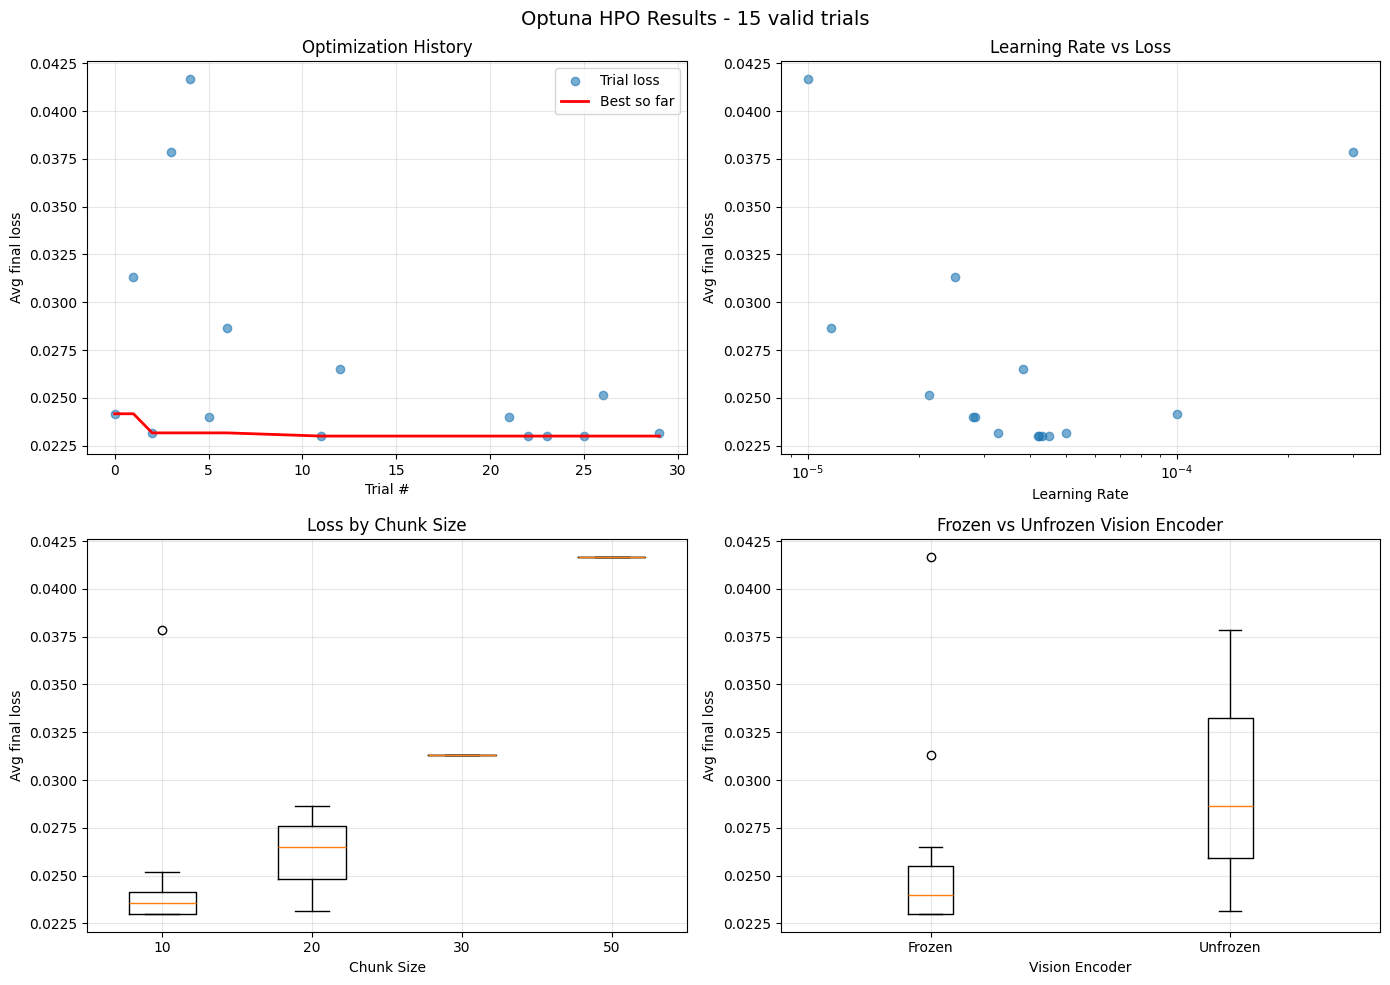

In [39]:
# === VISUALIZATION ===

import matplotlib.pyplot as plt
import numpy as np

completed_trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
valid_trials = [t for t in completed_trials if t.value is not None and t.value != float('inf')]

if len(valid_trials) >= 3:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle(f"Optuna HPO Results - {len(valid_trials)} valid trials", fontsize=14)

    # 1. Optimization history
    ax = axes[0, 0]
    trial_nums = [t.number for t in valid_trials]
    trial_vals = [t.value for t in valid_trials]
    best_so_far = [min(trial_vals[:i+1]) for i in range(len(trial_vals))]
    ax.scatter(trial_nums, trial_vals, alpha=0.6, label='Trial loss')
    ax.plot(trial_nums, best_so_far, 'r-', linewidth=2, label='Best so far')
    ax.set_xlabel('Trial #')
    ax.set_ylabel('Avg final loss')
    ax.set_title('Optimization History')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # 2. Learning rate vs loss
    ax = axes[0, 1]
    lrs = [t.params['learning_rate'] for t in valid_trials]
    vals = [t.value for t in valid_trials]
    ax.scatter(lrs, vals, alpha=0.6)
    ax.set_xscale('log')
    ax.set_xlabel('Learning Rate')
    ax.set_ylabel('Avg final loss')
    ax.set_title('Learning Rate vs Loss')
    ax.grid(True, alpha=0.3)

    # 3. Chunk size distribution
    ax = axes[1, 0]
    chunk_data, chunk_labels = [], []
    for cs in [10, 20, 30, 50]:
        cs_vals = [t.value for t in valid_trials if t.params['chunk_size'] == cs]
        if cs_vals:
            chunk_data.append(cs_vals)
            chunk_labels.append(str(cs))
    if chunk_data:
        ax.boxplot(chunk_data, labels=chunk_labels)
    ax.set_xlabel('Chunk Size')
    ax.set_ylabel('Avg final loss')
    ax.set_title('Loss by Chunk Size')
    ax.grid(True, alpha=0.3)

    # 4. Frozen vs unfrozen vision encoder
    ax = axes[1, 1]
    freeze_data, freeze_labels = [], []
    for fv in [True, False]:
        fv_vals = [t.value for t in valid_trials if t.params.get('freeze_vision_encoder', True) == fv]
        if fv_vals:
            freeze_data.append(fv_vals)
            freeze_labels.append('Frozen' if fv else 'Unfrozen')
    if freeze_data:
        ax.boxplot(freeze_data, labels=freeze_labels)
    ax.set_xlabel('Vision Encoder')
    ax.set_ylabel('Avg final loss')
    ax.set_title('Frozen vs Unfrozen Vision Encoder')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plot_path = OUTPUT_BASE / "optuna_results.png"
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    print(f"Plots saved to: {plot_path}")
    plt.show()
else:
    print(f"Only {len(valid_trials)} valid trials - need at least 3 for plots.")


Parameter Importances:
--------------------------------------------------
              learning_rate: 0.282 ##############
                 chunk_size: 0.279 #############
    color_jitter_brightness: 0.178 ########
             affine_degrees: 0.119 #####
           affine_translate: 0.050 ##
               weight_decay: 0.039 #
      color_jitter_contrast: 0.028 #
      freeze_vision_encoder: 0.018 
               action_ratio: 0.007 


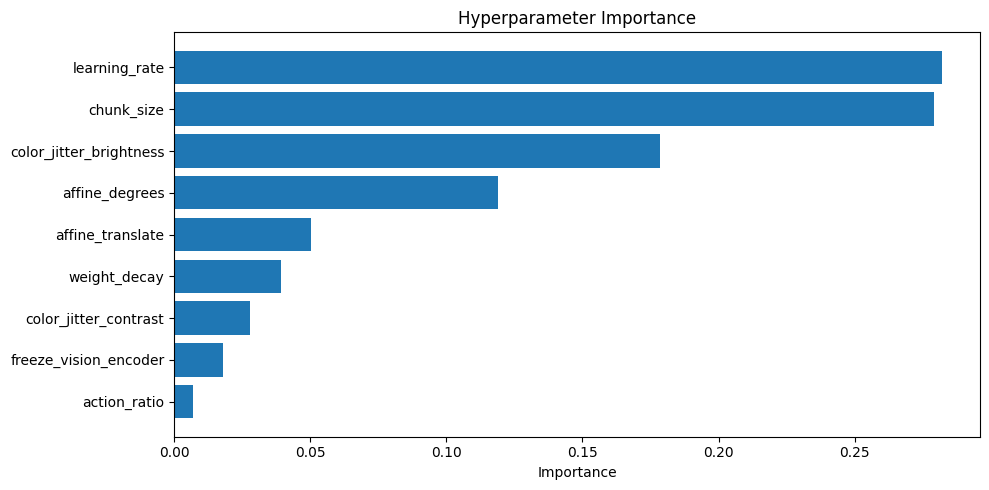

In [40]:
# === PARAM IMPORTANCE ===

if len(valid_trials) >= 8:
    try:
        importances = optuna.importance.get_param_importances(study)
        print("\nParameter Importances:")
        print("-" * 50)
        for param, imp in sorted(importances.items(), key=lambda x: -x[1]):
            bar = '#' * int(imp * 50)
            print(f"  {param:>25s}: {imp:.3f} {bar}")

        fig, ax = plt.subplots(figsize=(10, 5))
        params = list(importances.keys())
        values = list(importances.values())
        sorted_idx = np.argsort(values)
        ax.barh([params[i] for i in sorted_idx], [values[i] for i in sorted_idx])
        ax.set_xlabel('Importance')
        ax.set_title('Hyperparameter Importance')
        plt.tight_layout()
        plt.savefig(OUTPUT_BASE / "param_importance.png", dpi=150, bbox_inches='tight')
        plt.show()
    except Exception as e:
        print(f"Could not compute importance: {e}")
else:
    print(f"Need at least 8 valid trials for importance (have {len(valid_trials)})")

In [41]:
# === MANUAL BACKUP TO GOOGLE DRIVE (optional - auto-backup runs after every trial) ===
# Run this cell manually if you want to force a backup at any time.

import shutil as _shutil
_shutil.copy2(str(DB_PATH), DRIVE_BACKUP_PATH)
print(f"Study DB backed up to: {DRIVE_BACKUP_PATH}")

Study DB backed up to: /content/drive/MyDrive/optuna_smolvla_v3.db


In [42]:
# === RESUME AFTER COLAB DISCONNECT ===
# If Colab disconnected, re-run cells 1-9 (install, GPU check, config, imports, functions),
# then run THIS cell INSTEAD OF the "CREATE STUDY" cell (cell-10).

# Restore DB from Google Drive
# from google.colab import drive
# drive.mount('/content/drive')

# import shutil as _shutil
# _shutil.copy2(DRIVE_BACKUP_PATH, str(DB_PATH))
# print(f"Restored DB from: {DRIVE_BACKUP_PATH}")

# study = optuna.load_study(
#     study_name=STUDY_NAME,  # Uses STUDY_NAME from config cell
#     storage=f"sqlite:///{DB_PATH}",
# )
# completed = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
# pruned = len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED])
# failed = len([t for t in study.trials if t.state == optuna.trial.TrialState.FAIL])
# total = len(study.trials)
# remaining = N_TRIALS - total
# print(f"Loaded study '{STUDY_NAME}': {completed} completed, {pruned} pruned, {failed} failed, {remaining} remaining")
# if study.best_trial:
#     print(f"Best so far: trial #{study.best_trial.number} with loss {study.best_value:.5f}")

# if remaining > 0:
#     print(f"\nResuming optimization with {remaining} remaining trials...")

#     def drive_backup_callback(study, trial):
#         _shutil.copy2(str(DB_PATH), DRIVE_BACKUP_PATH)
#         c = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
#         p = len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED])
#         best_val = study.best_value if study.best_trial else float('inf')
#         print(f"  [Backed up to Drive | {c} done, {p} pruned | best: {best_val:.5f}]")

#     study.optimize(objective, n_trials=remaining, callbacks=[drive_backup_callback])
#     _shutil.copy2(str(DB_PATH), DRIVE_BACKUP_PATH)
#     print(f"\nResume complete! Final backup saved to Drive.")
# else:
#     print("All trials already completed! Skip to the RESULTS cell.")

In [43]:
# import optuna
# storage = f"sqlite:///{DB_PATH}"
# studies = optuna.study.get_all_study_summaries(storage)
# for s in studies:
#     print(f"  {s.study_name}: {s.n_trials} trials")